In [17]:
from matplotlib import pyplot as plt
import numpy as np
import collections

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.set_printoptions(edgeitems=2)

# Part1 Playing with the CNN (40 points):

In [ ]:
# Download Dataset
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

from torchvision import datasets, transforms, utils
# where to put the data
data_path = './'

In [ ]:
# Device Check
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Training on device {device}.")


Training on device cuda.


In [20]:
# this constructs a CIFAR10 dataset, selects the training part of it,
# downloads it if necessary, and adds additional transforms that we
# will need to convert each image to a pytorch tensor AND to provide
# a nice conversion of the RGB images into greyscale
cifar10 = datasets.CIFAR10(
    data_path, train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

## Extract the automobile and truck classes

In [ ]:
# automobile for 1, truck for 9
label_map = {1: 0, 9: 1}  # automobile(1) → 0, truck(9) → 1
class_names = ['automobile', 'truck']


cifar2 = [(img, label_map[label])
          for img, label in cifar10
          if label in [1, 9]]  

cifar2_val = [(img, label_map[label])
              for img, label in cifar10_val
              if label in [1, 9]]

## Model Definition

In [25]:
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [26]:
import datetime

def validate_epoch(model, loader):
    """Calculate accuracy for a given data loader"""
    correct = 0
    total = 0
    
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            outputs = model(imgs)
            _, predicted = torch.max(outputs, dim=1)
            total += labels.shape[0]
            correct += int((predicted == labels).sum())
    
    model.train()
    return correct / total

In [27]:
def training_loop_with_validation(n_epochs, optimizer, model, loss_fn, train_loader, val_loader):
    """Training loop that tracks both training and validation accuracy for each epoch"""
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        model.train()
        
        for imgs, labels in train_loader:
            # put the data onto the correct pytorch calculation device
            imgs = imgs.to(device)
            labels = labels.to(device)

            # put a batch through the model
            outputs = model(imgs)
            # determine the loss
            loss = loss_fn(outputs, labels)
            # zero the gradients and determine backpropagation
            optimizer.zero_grad()
            loss.backward()
            # do one step of optimization
            optimizer.step()
            # keep track of the loss
            loss_train += loss.item()

        # Calculate accuracies for this epoch
        train_acc = validate_epoch(model, train_loader)
        val_acc = validate_epoch(model, val_loader)
        
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {:.4f}, Train Acc: {:.4f}, Val Acc: {:.4f}'.format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader), train_acc, val_acc))
    
    return train_accuracies, val_accuracies

In [28]:
# Run training for 20 different seeds
n_seeds = 20
n_epochs = 100
all_train_accuracies = []
all_val_accuracies = []

In [29]:
print("Starting multi-seed training...")
for seed in range(n_seeds):
    print(f"\n=== Training with seed {seed} ===")
    
    # Set seed for reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Create data loaders
    train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)
    val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
    
    # Initialize model, optimizer, and loss function
    model = Net().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)  # ADAM optimizer with lr=1e-4
    loss_fn = nn.CrossEntropyLoss()
    
    # Train the model
    train_accs, val_accs = training_loop_with_validation(
        n_epochs=n_epochs,
        optimizer=optimizer,
        model=model,
        loss_fn=loss_fn,
        train_loader=train_loader,
        val_loader=val_loader
    )
    
    all_train_accuracies.append(train_accs)
    all_val_accuracies.append(val_accs)
    
    print(f"Seed {seed} - Final Train Acc: {train_accs[-1]:.4f}, Final Val Acc: {val_accs[-1]:.4f}")

Starting multi-seed training...

=== Training with seed 0 ===
2025-06-14 17:29:36.156154 Epoch 1, Training loss 0.6471, Train Acc: 0.6567, Val Acc: 0.6695
2025-06-14 17:29:40.657294 Epoch 10, Training loss 0.4083, Train Acc: 0.8264, Val Acc: 0.8030
2025-06-14 17:29:45.633426 Epoch 20, Training loss 0.3314, Train Acc: 0.8608, Val Acc: 0.8290
2025-06-14 17:29:50.573667 Epoch 30, Training loss 0.3026, Train Acc: 0.8784, Val Acc: 0.8440
2025-06-14 17:29:55.581956 Epoch 40, Training loss 0.2806, Train Acc: 0.8897, Val Acc: 0.8530
2025-06-14 17:30:00.651083 Epoch 50, Training loss 0.2623, Train Acc: 0.8951, Val Acc: 0.8595
2025-06-14 17:30:05.694425 Epoch 60, Training loss 0.2487, Train Acc: 0.9017, Val Acc: 0.8670
2025-06-14 17:30:10.720281 Epoch 70, Training loss 0.2342, Train Acc: 0.9097, Val Acc: 0.8645
2025-06-14 17:30:15.854092 Epoch 80, Training loss 0.2219, Train Acc: 0.9149, Val Acc: 0.8715
2025-06-14 17:30:21.244978 Epoch 90, Training loss 0.2119, Train Acc: 0.9223, Val Acc: 0.8685

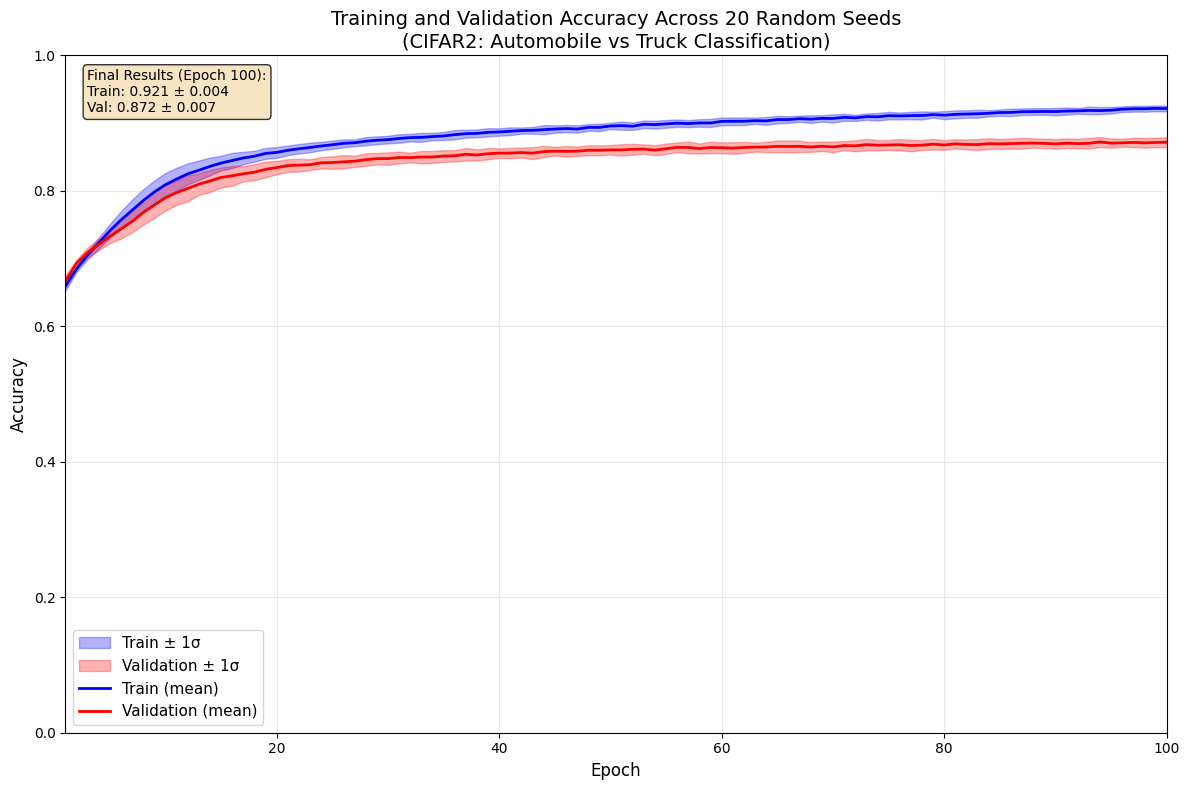


=== Summary Statistics ===
Final Training Accuracy: 0.9215 ± 0.0043
Final Validation Accuracy: 0.8718 ± 0.0075
Best mean validation accuracy: 0.8721 at epoch 94


In [ ]:
# Convert to numpy arrays for easier manipulation
all_train_accuracies = np.array(all_train_accuracies)  
all_val_accuracies = np.array(all_val_accuracies)      

# Calculate mean and standard deviation across seeds for each epoch
train_mean = np.mean(all_train_accuracies, axis=0)
train_std = np.std(all_train_accuracies, axis=0)
val_mean = np.mean(all_val_accuracies, axis=0)
val_std = np.std(all_val_accuracies, axis=0)

# Create the plot
plt.figure(figsize=(12, 8))
epochs = np.arange(1, 101)  # 100 epochs

# Plot with error bars (shaded regions)
plt.fill_between(epochs, train_mean - train_std, train_mean + train_std, 
                 alpha=0.3, color='blue', label='Train ± 1σ')
plt.fill_between(epochs, val_mean - val_std, val_mean + val_std, 
                 alpha=0.3, color='red', label='Validation ± 1σ')

# Plot mean lines
plt.plot(epochs, train_mean, 'b-', linewidth=2, label='Train (mean)')
plt.plot(epochs, val_mean, 'r-', linewidth=2, label='Validation (mean)')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training and Validation Accuracy Across 20 Random Seeds\n(CIFAR2: Automobile vs Truck Classification)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(1, 100)
plt.ylim(0, 1)

# Add text box with final results to check how it ended
final_train_mean = train_mean[-1]
final_train_std = train_std[-1]
final_val_mean = val_mean[-1]
final_val_std = val_std[-1]

textstr = f'Final Results (Epoch 100):\n'
textstr += f'Train: {final_train_mean:.3f} ± {final_train_std:.3f}\n'
textstr += f'Val: {final_val_mean:.3f} ± {final_val_std:.3f}'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\n=== Summary Statistics ===")
print(f"Final Training Accuracy: {final_train_mean:.4f} ± {final_train_std:.4f}")
print(f"Final Validation Accuracy: {final_val_mean:.4f} ± {final_val_std:.4f}")
print(f"Best mean validation accuracy: {np.max(val_mean):.4f} at epoch {np.argmax(val_mean) + 1}")

In [40]:
# Computing largest, smallest, and average standard deviation for training and validation.

print(f"Largest train std: {max(train_std)}, epoch: {np.argmax(train_std)}")
print(f"Smallest train std: {min(train_std)}, epoch: {np.argmin(train_std)}")
print(f"Largest val std: {max(val_std)}, epoch: {np.argmax(val_std)}")
print(f"Smallest val std: {min(val_std)}, epoch: {np.argmin(val_std)}")
print(f"Average train std: {np.mean(train_std)}, Median train std: {np.median(train_std)}")
print(f"Average val std: {np.mean(val_std)}, Median val std: {np.median(val_std)}")


Largest train std: 0.017267944289926354, epoch: 9
Smallest train std: 0.004169277515349624, epoch: 95
Largest val std: 0.019117580260064295, epoch: 9
Smallest val std: 0.005604629782599373, epoch: 1
Average train std: 0.006654574441728606, Median train std: 0.00567457163153375
Average val std: 0.008951038319888745, Median val std: 0.008074418020050515


## Question 1: Did the network train well?
#### The network seem to have trained well with a validation accuracy 87% achieved. Which is a descent result. But it seems overfitted since at epoch 20~40 the Accuracy seems flatten. 

## Question 2: Do you think the variability across seeds is large or small? Why?
#### We believe the variability between the seeds to be small, which is based on the following computed statistics:

| Statistic           | Training Standard Deviation | Validation Standard Deviation |
|---------------------|----------------------------|-------------------------------|
| **Average**         | 0.0067                     | 0.0090                        |
| **Median**          | 0.0057                     | 0.0081                        |

All measurements which are below 0.01 in average/median which indicate very small variability across the seeds.

## Part1.3 Extracting 100 random images

In [ ]:
import random

# Convert the datasets to a list and shuffle in place
random.seed(42) # Set the same seed for reproducability
cifar10_list = list(cifar10)
random.shuffle(cifar10_list)

# Initialize counters and filtered datasets
count2 = 0
cifar2_images = []
cifar2_labels = []

# Filter the shuffled datasets - except automobile or truck
for (img, label) in cifar10_list:
    if label not in [1, 9] and count2 < 100: 
        cifar2_images.append(img)
        cifar2_labels.append(label)
        count2 += 1

# Print results
print(f"Length cifar2: {len(cifar2_images)}")

Length cifar2: 100


## Using model to predict on the 100 random images and count how many times the model believed the image to either be automobile or truck.

In [ ]:
import pprint

dataloader = torch.utils.data.DataLoader(cifar2_images, batch_size=1, shuffle=True)

cifar10_classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# 0 → "automobile", 1 → "truck"
prediction_to_class = {0: "automobile", 1: "truck"}

model.eval()

prediction_counter = {f"{cifar10_classes[label]}": {"automobile": 0, "truck": 0, "confidence": []} for label in cifar2_labels}
with torch.no_grad():
    for i, img in enumerate(dataloader):
        img = img.to(device)
        output = model(img)

        probabilities = F.softmax(output, dim=1).flatten() # Get the confidence for each class with softmax

        prediction_index = torch.argmax(probabilities).item()
        _, prediction = torch.max(output, 1)
        
        predicted_class = prediction_to_class[prediction.item()]
        
        prediction_counter[cifar10_classes[cifar2_labels[i]]][predicted_class] += 1 
        prediction_counter[cifar10_classes[cifar2_labels[i]]]["confidence"].append(probabilities[prediction_index].item())

pprint.pprint(prediction_counter)

{'airplane': {'automobile': 5,
              'confidence': [0.9750508069992065,
                             0.8606237173080444,
                             0.5048622488975525,
                             0.7877034544944763,
                             0.9604302048683167,
                             0.7556323409080505,
                             0.9076967835426331,
                             0.7788716554641724,
                             0.857641875743866,
                             0.5719354152679443,
                             0.9956810474395752,
                             0.6635867357254028,
                             0.9245979189872742,
                             0.8191065788269043,
                             0.996841549873352,
                             0.6255032420158386,
                             0.7421514391899109],
              'truck': 12},
 'bird': {'automobile': 1,
          'confidence': [0.9085023403167725,
                         0.9765321016

## Display predictions results in histograms.

C:\Users\jack\AppData\Local\Temp\ipykernel_23108\1056449131.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([prediction_counter[cls]["confidence"] for cls in classes], labels=classes)


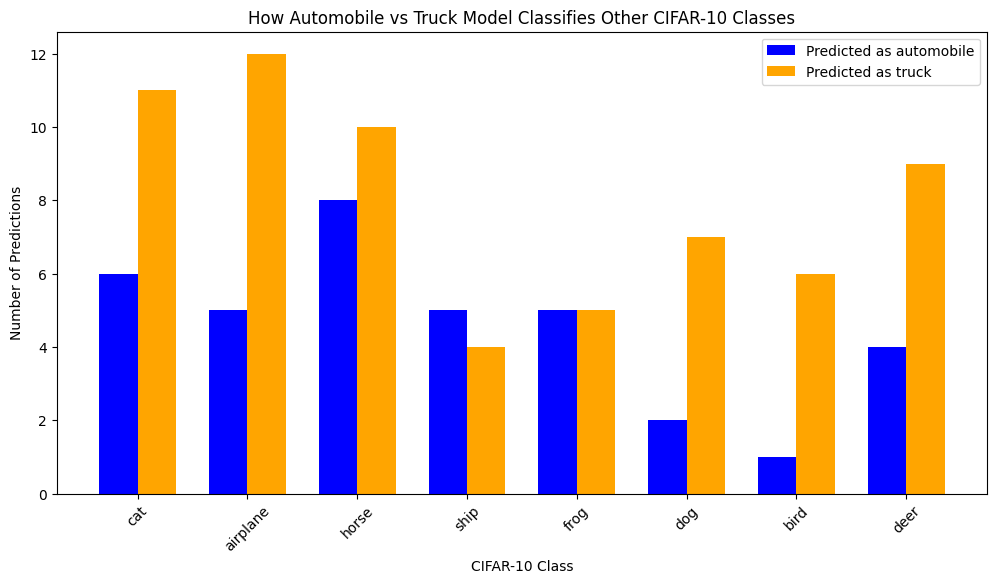

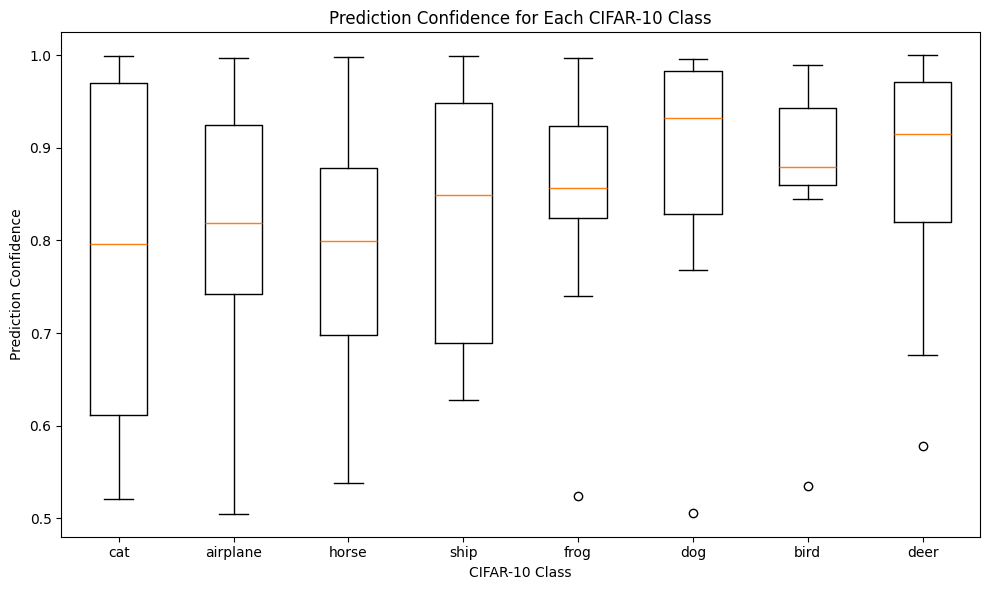

In [ ]:
# Extract data for plotting 
classes = list(prediction_counter.keys())
automobile_counts = [prediction_counter[cls]["automobile"] for cls in classes]  # deer_counts → automobile_counts
truck_counts = [prediction_counter[cls]["truck"] for cls in classes]  # horse_counts → truck_counts

# Set bar positions and width
x = np.arange(len(classes))
width = 0.35

# histogram plot
plt.figure(1, figsize=(12, 6))
plt.bar(x - width/2, automobile_counts, width, label='Predicted as automobile', color='blue')  
plt.bar(x + width/2, truck_counts, width, label='Predicted as truck', color='orange')  

plt.xlabel("CIFAR-10 Class")
plt.ylabel("Number of Predictions")
plt.title("How Automobile vs Truck Model Classifies Other CIFAR-10 Classes") 
plt.xticks(x, classes, rotation=45)
plt.legend()

# Boxplot for confidence of prediction
plt.figure(2, figsize=(10, 6))
plt.boxplot([prediction_counter[cls]["confidence"] for cls in classes], labels=classes)
plt.xlabel("CIFAR-10 Class")
plt.ylabel("Prediction Confidence")
plt.title("Prediction Confidence for Each CIFAR-10 Class")  

plt.tight_layout()
plt.show()

## Question 3: Load 100 random images from OTHER classes (so, NEITHER automobiles nor trucks) and put them into the network - how are the images classified? Do these results make “sense”?

#### When examining the predictions for each CIFAR-10 class except automobiles and trucks, some classifications don’t make much sense. One of the more noticeable cases is the airplane class, which has been predicted as truck 11 times and 6 times as automobiles, indicating that the model is confident in labeling airplane as truck. (Could be because the airplane, car, trucks front view could be similar to each other?)

#### This raises the question of whether the model truly understands the underlying features of a truck. This questioning of the model’s ability to grasp the distinguishing features of automobiles and truck is further strengthened by the confidence boxplots, where the median confidence is above 90% for the majority of classes. 

#### These results are puzzling, as it would seem more reasonable if the confidence levels were much lower. Maybe this result could be improved by training the model to also predict an unknown class if it is unsure.

## Question 4: Taking into account the results from Question 3 - would you use this network to classify automobiles versus trucks in the “real” world?

#### No we would not use this network to classify auomobiles versus trucks in the real world. Taking into account the results from Question 3, if there is a different shape of automobiles appears(ex: New shape that are similar to the front of the airplane or Frog), it would identify the new automobile as a truck.

# Part2 Pytorch CNN comparison (40 points): 

In [ ]:
# NetWidth with ReLU
class NetWidth(nn.Module):
    def __init__(self, n_ch1=32):
        super().__init__()
        self.n_ch1 = n_ch1
        self.conv1 = nn.Conv2d(3, n_ch1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_ch1, n_ch1 // 2, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * n_ch1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(F.relu(self.conv1(x)), 2)  
        out = F.max_pool2d(F.relu(self.conv2(out)), 2) 
        out = out.view(-1, 8 * 8 * self.n_ch1 // 2)
        out = F.relu(self.fc1(out))  
        out = self.fc2(out)
        return out

# NetDropout with ReLU
class NetDropout(nn.Module):
    def __init__(self, n_ch1=32):
        super().__init__()
        self.n_ch1 = n_ch1
        self.conv1 = nn.Conv2d(3, n_ch1, kernel_size=3, padding=1)
        self.conv1_dropout = nn.Dropout2d(p=0.4)
        self.conv2 = nn.Conv2d(n_ch1, n_ch1 // 2, kernel_size=3, padding=1)
        self.conv2_dropout = nn.Dropout2d(p=0.4)
        self.fc1 = nn.Linear(8 * 8 * n_ch1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(F.relu(self.conv1(x)), 2)  
        out = self.conv1_dropout(out)
        out = F.max_pool2d(F.relu(self.conv2(out)), 2)
        out = self.conv2_dropout(out)
        out = out.view(-1, 8 * 8 * self.n_ch1 // 2)
        out = F.relu(self.fc1(out))  
        out = self.fc2(out)
        return out

# NetBatchNormalization with ReLU
class NetBatchNormalization(nn.Module):
    def __init__(self, n_ch1=32):
        super().__init__()
        self.n_ch1 = n_ch1
        self.conv1 = nn.Conv2d(3, n_ch1, kernel_size=3, padding=1)
        self.conv1_batchnorm = nn.BatchNorm2d(n_ch1)
        self.conv2 = nn.Conv2d(n_ch1, n_ch1 // 2, kernel_size=3, padding=1)
        self.conv2_batchnorm = nn.BatchNorm2d(n_ch1 // 2)
        self.fc1 = nn.Linear(8 * 8 * n_ch1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = self.conv1_batchnorm(self.conv1(x))
        out = F.max_pool2d(F.relu(out), 2)  
        out = self.conv2_batchnorm(self.conv2(out))
        out = F.max_pool2d(F.relu(out), 2)  
        out = out.view(-1, 8 * 8 * self.n_ch1 // 2)
        out = F.relu(self.fc1(out))  
        out = self.fc2(out)
        return out

# NetSkip with ReLU
class NetSkip(nn.Module):
    def __init__(self, n_ch1=32):
        super().__init__()
        self.n_ch1 = n_ch1
        self.conv1 = nn.Conv2d(3, n_ch1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_ch1, n_ch1 // 2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(n_ch1 // 2, n_ch1 // 2, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * n_ch1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(F.relu(self.conv1(x)), 2)  
        out = F.max_pool2d(F.relu(self.conv2(out)), 2) 
        in_layer3 = out
        out = F.max_pool2d(F.relu(self.conv3(out)) + in_layer3, 2)  
        out = out.view(-1, 4 * 4 * self.n_ch1 // 2)
        out = F.relu(self.fc1(out))  
        out = self.fc2(out)
        return out

# ResBlock 
class ResBlock(nn.Module):
    def __init__(self, n_ch):
        super(ResBlock, self).__init__()
        self.conv = nn.Conv2d(n_ch, n_ch, kernel_size=3, padding=1, bias=False)
        self.batch_norm = nn.BatchNorm2d(n_ch)
        torch.nn.init.constant_(self.batch_norm.weight, 0.5)
        torch.nn.init.zeros_(self.batch_norm.bias)
        torch.nn.init.kaiming_normal_(self.conv.weight, nonlinearity='relu')
        
    def forward(self, x):
        out = self.conv(x)
        out = self.batch_norm(out)
        out = F.relu(out)  # 이미 ReLU
        return out + x

class NetResDeep(nn.Module):
    def __init__(self, n_ch1=32, n_blocks=10):
        super().__init__()
        self.n_ch1 = n_ch1
        self.conv1 = nn.Conv2d(3, n_ch1, kernel_size=3, padding=1)
        self.resblocks = nn.Sequential(*(n_blocks * [ResBlock(n_ch1)]))
        self.fc1 = nn.Linear(8 * 8 * n_ch1, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(F.relu(self.conv1(x)), 2)  
        out = self.resblocks(out)
        out = F.max_pool2d(out, 2)
        out = out.view(-1, 8 * 8 * self.n_ch1)
        out = F.relu(self.fc1(out))  
        out = self.fc2(out)
        return out

# NetWidthProject with ReLU
class NetWidthProject(nn.Module):
    def __init__(self, n_ch1=32):
        super().__init__()
        self.n_ch1 = n_ch1
        self.conv1 = nn.Conv2d(3, n_ch1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_ch1, n_ch1 // 2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(n_ch1 // 2, n_ch1 // 2, kernel_size=1)
        self.fc1 = nn.Linear(8 * 8 * n_ch1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(F.relu(self.conv1(x)), 2) 
        out = F.max_pool2d(F.relu(self.conv2(out)), 2)
        out = F.relu(self.conv3(out))  
        out = out.view(-1, 8 * 8 * self.n_ch1 // 2)
        out = F.relu(self.fc1(out))  
        out = self.fc2(out)
        return out

# NetWidthEmbed with ReLU
class NetWidthEmbed(nn.Module):
    def __init__(self, n_ch1=32):
        super().__init__()
        self.n_ch1 = n_ch1
        self.conv1 = nn.Conv2d(3, n_ch1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_ch1, n_ch1 // 2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(n_ch1//2, n_ch1//4, kernel_size=1)
        self.fc1 = nn.Linear(8 * 8 * n_ch1 // 4, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(F.relu(self.conv1(x)), 2)  
        out = F.max_pool2d(F.relu(self.conv2(out)), 2) 
        out = F.relu(self.conv3(out))  
        out = out.view(-1, 8 * 8 * self.n_ch1 // 4)
        out = F.relu(self.fc1(out))  
        out = self.fc2(out)
        return out

In [ ]:
print("="*70)
print("PART 2: Training all networks systematically")
print("CIFAR2 Classification: Automobile vs Truck")
print("="*70)

# Models to train
models_to_train = [NetWidth, NetDropout, NetBatchNormalization, NetSkip, NetResDeep, NetWidthProject, NetWidthEmbed]

# Hyperparameters
learning_rate = 1e-4
loss_fn = nn.CrossEntropyLoss()
batch_size = 64
num_epochs = 100
num_seeds = 20

PART 2: Training all networks systematically
CIFAR2 Classification: Automobile vs Truck


In [ ]:
results = {}

# also include the original results from Net from Part 1
results['Net_tanh'] = {
    'training_acc': [],
    'validation_acc': [],
    'final_train_accs': all_train_accuracies[:, -1],  
    'final_val_accs': all_val_accuracies[:, -1]       
}


In [ ]:
# Model training starts here
for model_class in models_to_train:
    model_name = model_class.__name__
    print(f"\nTraining: {model_name}")
    
    results[model_name] = {
        'training_acc': [],
        'validation_acc': [],
        'final_train_accs': [],
        'final_val_accs': []
    }
    
    for seed in range(num_seeds):
        if seed % 5 == 0:
            print(f"  Seed {seed}...")
        
        torch.manual_seed(seed)
        np.random.seed(seed)
        model = model_class().to(device)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        train_loader = torch.utils.data.DataLoader(cifar2, batch_size=batch_size, shuffle=True)
        val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=batch_size, shuffle=False)
        
        train_accs, val_accs = training_loop_with_validation(
            n_epochs=num_epochs,
            optimizer=optimizer,
            model=model,
            loss_fn=loss_fn,
            train_loader=train_loader,
            val_loader=val_loader
        )
        
        # new result here
        results[model_name]['training_acc'].append(train_accs)
        results[model_name]['validation_acc'].append(val_accs)
        results[model_name]['final_train_accs'].append(train_accs[-1])
        results[model_name]['final_val_accs'].append(val_accs[-1])
    
    # Current model summary saving here
    final_train_mean = np.mean(results[model_name]['final_train_accs'])
    final_val_mean = np.mean(results[model_name]['final_val_accs'])
    print(f"  {model_name} - Train: {final_train_mean:.4f}, Val: {final_val_mean:.4f}")

print("\nAll models trained successfully!")


Training: NetWidth
  Seed 0...
2025-06-14 18:10:11.620956 Epoch 1, Training loss 0.6352, Train Acc: 0.6806, Val Acc: 0.6865
2025-06-14 18:10:17.049673 Epoch 10, Training loss 0.3592, Train Acc: 0.8535, Val Acc: 0.8370
2025-06-14 18:10:23.091426 Epoch 20, Training loss 0.2923, Train Acc: 0.8871, Val Acc: 0.8600
2025-06-14 18:10:29.214507 Epoch 30, Training loss 0.2434, Train Acc: 0.9101, Val Acc: 0.8745
2025-06-14 18:10:35.335075 Epoch 40, Training loss 0.2122, Train Acc: 0.9250, Val Acc: 0.8825
2025-06-14 18:10:41.407213 Epoch 50, Training loss 0.1879, Train Acc: 0.9355, Val Acc: 0.8850
2025-06-14 18:10:47.435658 Epoch 60, Training loss 0.1660, Train Acc: 0.9407, Val Acc: 0.8880
2025-06-14 18:10:53.498287 Epoch 70, Training loss 0.1462, Train Acc: 0.9531, Val Acc: 0.8910
2025-06-14 18:10:59.620247 Epoch 80, Training loss 0.1230, Train Acc: 0.9555, Val Acc: 0.8890
2025-06-14 18:11:05.691837 Epoch 90, Training loss 0.1079, Train Acc: 0.9671, Val Acc: 0.8925
2025-06-14 18:11:11.800973 Ep

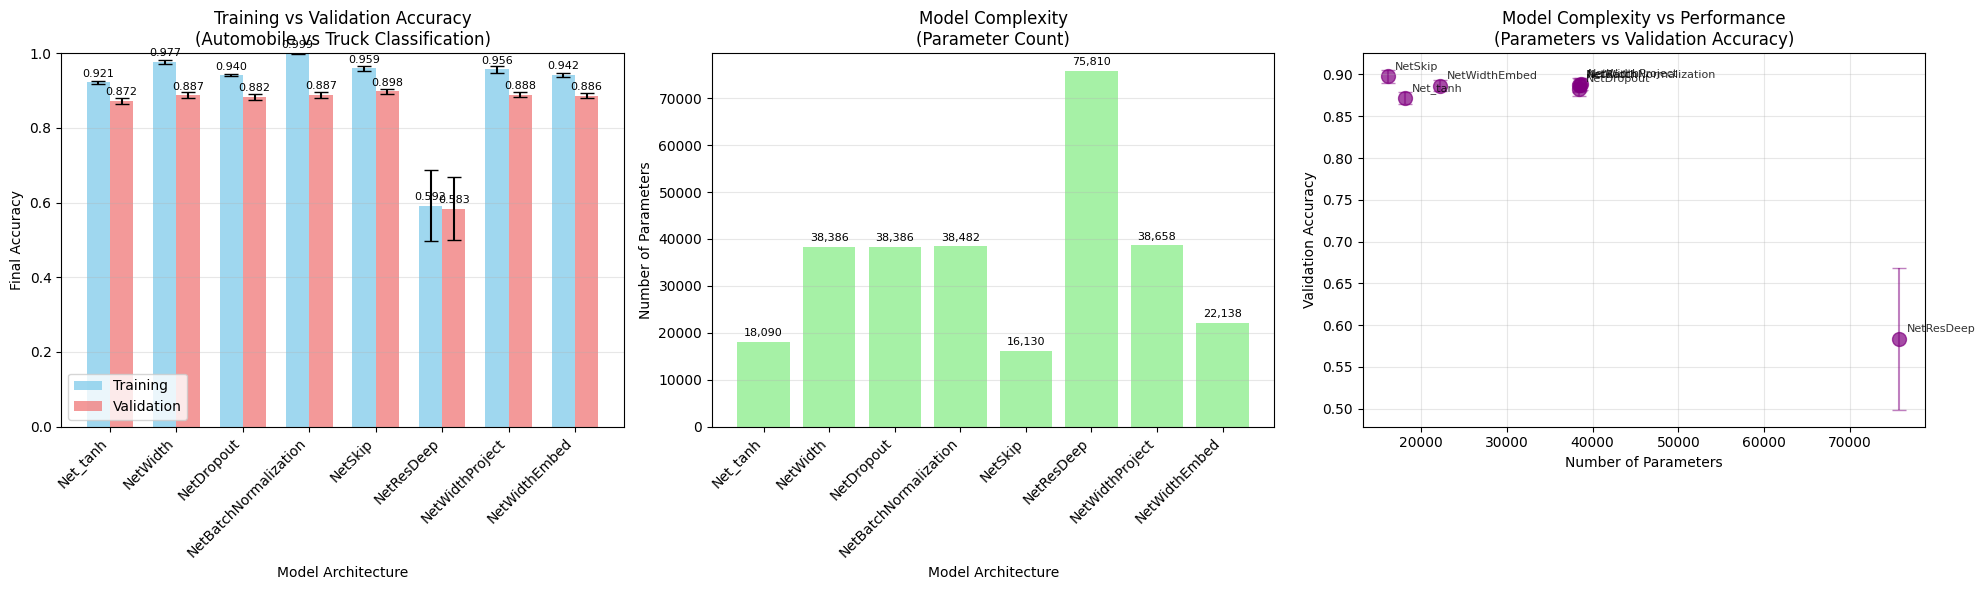

In [ ]:
# =====================
# Result Analysis and Visualization
# =====================

# Name of the Models
model_names = ['Net_tanh'] + [model_class.__name__ for model_class in models_to_train]

# Calculate the parameters(for comparison)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# each models parameters
model_params = [count_parameters(Net())]  # the basic Net (tanh) from part1
model_params.extend([count_parameters(model_class()) for model_class in models_to_train])

train_means = []
train_stds = []
val_means = []
val_stds = []

for model_name in model_names:
    train_means.append(np.mean(results[model_name]['final_train_accs']))
    train_stds.append(np.std(results[model_name]['final_train_accs']))
    val_means.append(np.mean(results[model_name]['final_val_accs']))
    val_stds.append(np.std(results[model_name]['final_val_accs']))

# Visualization starts here
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

x = np.arange(len(model_names))
width = 0.35

train_bars = ax1.bar(x - width/2, train_means, width, label='Training', 
                    yerr=train_stds, capsize=5, color='skyblue', alpha=0.8)
val_bars = ax1.bar(x + width/2, val_means, width, label='Validation', 
                  yerr=val_stds, capsize=5, color='lightcoral', alpha=0.8)

ax1.set_ylabel('Final Accuracy')
ax1.set_xlabel('Model Architecture')
ax1.set_title('Training vs Validation Accuracy\n(Automobile vs Truck Classification)')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 1.0)

for i, (train_bar, val_bar) in enumerate(zip(train_bars, val_bars)):
    ax1.text(train_bar.get_x() + train_bar.get_width()/2, 
            train_bar.get_height() + 0.01,
            f'{train_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=8)
    ax1.text(val_bar.get_x() + val_bar.get_width()/2, 
            val_bar.get_height() + 0.01,
            f'{val_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=8)

ax2.bar(x, model_params, color='lightgreen', alpha=0.8)
ax2.set_ylabel('Number of Parameters')
ax2.set_xlabel('Model Architecture')
ax2.set_title('Model Complexity\n(Parameter Count)')
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

for i, bar in enumerate(ax2.patches):
    ax2.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + max(model_params)*0.01,
            f'{model_params[i]:,}', 
            ha='center', va='bottom', fontsize=8)

ax3.scatter(model_params, val_means, c='purple', s=100, alpha=0.7)
ax3.errorbar(model_params, val_means, yerr=val_stds, fmt='none', 
            capsize=5, color='purple', alpha=0.5)

for i, model_name in enumerate(model_names):
    ax3.annotate(model_name, (model_params[i], val_means[i]), 
                xytext=(5, 5), textcoords='offset points', 
                fontsize=8, alpha=0.8)

ax3.set_xlabel('Number of Parameters')
ax3.set_ylabel('Validation Accuracy')
ax3.set_title('Model Complexity vs Performance\n(Parameters vs Validation Accuracy)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)

print(f"{'Model':<25} {'Parameters':<12} {'Train Acc':<12} {'Val Acc':<12} {'Gap':<8}")
print("-" * 70)

for i, model_name in enumerate(model_names):
    gap = train_means[i] - val_means[i]
    print(f"{model_name:<25} {model_params[i]:<12,} {train_means[i]:<12.4f} {val_means[i]:<12.4f} {gap:<8.4f}")

# The best model performance
best_val_idx = np.argmax(val_means)
print(f"\nBest performing model: {model_names[best_val_idx]}")
print(f"Validation accuracy: {val_means[best_val_idx]:.4f} ± {val_stds[best_val_idx]:.4f}")
print(f"Parameters: {model_params[best_val_idx]:,}")

tanh_acc = val_means[0]
relu_accs = val_means[1:]
avg_relu_acc = np.mean(relu_accs)
print(f"\nActivation Function Comparison:")
print(f"Net (tanh): {tanh_acc:.4f}")
print(f"ReLU models average: {avg_relu_acc:.4f}")
print(f"Improvement: {avg_relu_acc - tanh_acc:+.4f}")

print("\nPART 2 completed! Ready for PART 3...")


FINAL RESULTS SUMMARY
Model                     Parameters   Train Acc    Val Acc      Gap     
----------------------------------------------------------------------
Net_tanh                  18,090       0.9215       0.8718       0.0497  
NetWidth                  38,386       0.9766       0.8870       0.0896  
NetDropout                38,386       0.9403       0.8822       0.0581  
NetBatchNormalization     38,482       0.9993       0.8875       0.1118  
NetSkip                   16,130       0.9592       0.8976       0.0616  
NetResDeep                75,810       0.5921       0.5835       0.0087  
NetWidthProject           38,658       0.9564       0.8884       0.0680  
NetWidthEmbed             22,138       0.9418       0.8864       0.0554  

Best performing model: NetSkip
Validation accuracy: 0.8976 ± 0.0076
Parameters: 16,130

Activation Function Comparison:
Net (tanh): 0.8718
ReLU models average: 0.8447
Improvement: -0.0271

PART 2 completed! Ready for PART 3...


## Question 1: Are the resulting architectures (significantly) different in terms of their accuracies (for training and validation)?

#### The architectures are mostly similar EXCEPT NetResDeep. This can be observed in the left plot above, where most of the model has above 90% training accuracy and above 87% of validation accuracy except the NetResDeep. We believe that because NetResDeep has such a huge parameters, the number of epoch or data we used is not enough to fully train the model. 

## Question 2: Taking into account the number of parameters in each model, is there a relationship between training accuracy and number of parameters? (For this, you can also use another, adequate plot to support your answer)

#### In the right plot above, the parameters for each model is plotted with respect to validation accuracy. The NetResDeep model has significantly more parameters than all other models, but, performance of NetResDeep is much lower than any other model(with 0.58). In fact, NetSkip has the least parameter but has the highest validation accuracy. 

#### From here, Since it was a simple binary task(automobile vs truck), distinguishing between cars and trucks does not require etremely complex features that very deep networks provide. And, NetSkip's architecture provides enough capacity to learn key distinguishing features. Therefore, we could conclude that simpler architectures often outperform verydeep networks because they avoid overfitting while capturing essential distinguishing features. 

# Part3 Pytorch Multiclass (60 points):

In [61]:
# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4915, 0.4823, 0.4468),
                        (0.2470, 0.2435, 0.2616))
])

# Data path and loading full CIFAR-10
data_path = './'
cifar10 = datasets.CIFAR10(data_path, train=True, download=True, transform=transform)
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True, transform=transform)

# CIFAR-10 classes
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
# This time, it was NetSkip10
# It is very interesting that depends on the object type, different structure becomes the best model
# Fix NetSkip for 10-class CIFAR10
class NetSkip10(nn.Module):
    def __init__(self, n_ch1=32):
        super().__init__()
        self.n_ch1 = n_ch1
        self.conv1 = nn.Conv2d(3, n_ch1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_ch1, n_ch1 // 2, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(n_ch1 // 2, n_ch1 // 2, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * n_ch1 // 2, 32)
        self.fc2 = nn.Linear(32, 10)  # 2 → 10 classes
        
    def forward(self, x):
        out = F.max_pool2d(F.relu(self.conv1(x)), 2)  
        out = F.max_pool2d(F.relu(self.conv2(out)), 2)
        in_layer3 = out  
        out = F.max_pool2d(F.relu(self.conv3(out)) + in_layer3, 2)  
        out = out.view(-1, 4 * 4 * self.n_ch1 // 2)  
        out = F.relu(self.fc1(out))
        out = self.fc2(out)  
        return out

# Debugging purpose
test_model = NetSkip10()
test_input = torch.randn(1, 3, 32, 32)  
test_output = test_model(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")
print(f"Expected output shape: [1, 10]")
print(f"Model parameters: {sum(p.numel() for p in test_model.parameters()):,}")

# check model structure
print("\nModel architecture:")
print(test_model)


Input shape: torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 10])
Expected output shape: [1, 10]
Model parameters: 16,394

Model architecture:
NetSkip10(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=256, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)


In [68]:
# Training loop with confusion matrix collection
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader, val_loader, device):
    train_acc_history = []
    val_acc_history = []
    
    # Initialize confusion matrices
    train_confusion = np.zeros((10, 10))
    val_confusion = np.zeros((10, 10))
    
    for epoch in range(1, n_epochs + 1):
        model.train()
        correct_train = 0
        total_train = 0
        
        # Training phase
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)
            labels = labels.to(device=device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs, dim=1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
            # Update confusion matrix for last epoch
            if epoch == n_epochs:
                for true, pred in zip(labels.cpu(), predicted.cpu()):
                    train_confusion[true, pred] += 1
        
        train_accuracy = correct_train / total_train
        train_acc_history.append(train_accuracy)
        
        # Validation phase
        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device=device)
                labels = labels.to(device=device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                
                # Update confusion matrix for last epoch
                if epoch == n_epochs:
                    for true, pred in zip(labels.cpu(), predicted.cpu()):
                        val_confusion[true, pred] += 1
        
        val_accuracy = correct_val / total_val
        val_acc_history.append(val_accuracy)
        
        if epoch == 1 or epoch % 20 == 0:
            print(f"Epoch {epoch}, Training accuracy: {train_accuracy:.4f}, Validation accuracy: {val_accuracy:.4f}")
    
    return train_acc_history, val_acc_history, train_confusion, val_confusion


In [ ]:
# Set device and parameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")

# PART 3 parameters 
batch_size = 64
n_epochs = 200
n_seeds = 10  

# Data loaders for full CIFAR-10
train_loader = torch.utils.data.DataLoader(cifar10, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(cifar10_val, batch_size=batch_size, shuffle=False)

print(f"Training dataset size: {len(cifar10)}")
print(f"Validation dataset size: {len(cifar10_val)}")
print(f"Training with {n_seeds} seeds for {n_epochs} epochs each")
print("Note: This will take much longer due to 10-class classification!")

# Arrays to store results
all_train_acc = []
all_val_acc = []
all_train_confusion = []
all_val_confusion = []

# Training loop over seeds
for seed in range(n_seeds):
    print(f"\n{'='*50}")
    print(f"Training with seed {seed+1}/{n_seeds}")
    print(f"{'='*50}")
    
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    model = NetSkip10().to(device=device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    
    train_acc_history, val_acc_history, train_conf, val_conf = training_loop(
        n_epochs=n_epochs,
        optimizer=optimizer,
        model=model,
        loss_fn=loss_fn,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device
    )
    
    all_train_acc.append(train_acc_history)
    all_val_acc.append(val_acc_history)
    all_train_confusion.append(train_conf)
    all_val_confusion.append(val_conf)
    
    final_train = train_acc_history[-1]
    final_val = val_acc_history[-1]
    print(f"Seed {seed} completed - Train: {final_train:.4f}, Val: {final_val:.4f}")
    

print(f"\n{'='*60}")
print("All seeds training completed!")
print(f"{'='*60}")

# Convert to numpy arrays for easier processing
all_train_acc = np.array(all_train_acc)  
all_val_acc = np.array(all_val_acc)      

# Final statistics
final_train_mean = np.mean(all_train_acc[:, -1])
final_train_std = np.std(all_train_acc[:, -1])
final_val_mean = np.mean(all_val_acc[:, -1])
final_val_std = np.std(all_val_acc[:, -1])

print(f"\nFINAL RESULTS SUMMARY:")
print(f"Training Accuracy:   {final_train_mean:.4f} ± {final_train_std:.4f}")
print(f"Validation Accuracy: {final_val_mean:.4f} ± {final_val_std:.4f}")
print(f"Generalization Gap:  {final_train_mean - final_val_mean:.4f}")

print(f"\nReady for plotting and confusion matrix analysis!")
print(f"- all_train_acc shape: {all_train_acc.shape}")
print(f"- all_val_acc shape: {all_val_acc.shape}")
print(f"- Number of confusion matrices: {len(all_train_confusion)} (train), {len(all_val_confusion)} (val)")

Training on device: cuda
Training dataset size: 50000
Validation dataset size: 10000
Training with 10 seeds for 200 epochs each
Note: This will take much longer due to 10-class classification!

Training with seed 1/10
Epoch 1, Training accuracy: 0.2985, Validation accuracy: 0.4023


In [ ]:
import seaborn as sns

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

print("Analyzing results and creating visualizations...")

# Convert to numpy arrays and calculate statistics
all_train_acc = np.array(all_train_acc)
all_val_acc = np.array(all_val_acc)
mean_train_acc = np.mean(all_train_acc, axis=0)
std_train_acc = np.std(all_train_acc, axis=0)
mean_val_acc = np.mean(all_val_acc, axis=0)
std_val_acc = np.std(all_val_acc, axis=0)

print(f"Accuracy arrays shape: Train {all_train_acc.shape}, Val {all_val_acc.shape}")

# Calculate average confusion matrices
avg_train_confusion = np.mean(all_train_confusion, axis=0)
avg_val_confusion = np.mean(all_val_confusion, axis=0)

print(f"Average confusion matrices calculated")
print(f"Train confusion shape: {avg_train_confusion.shape}")
print(f"Val confusion shape: {avg_val_confusion.shape}")

# Convert to percentages 
avg_train_confusion_pct = np.zeros_like(avg_train_confusion)
avg_val_confusion_pct = np.zeros_like(avg_val_confusion)

for i in range(10):
    row_sum = avg_train_confusion[i].sum()
    if row_sum > 0:
        avg_train_confusion_pct[i] = avg_train_confusion[i] / row_sum * 100
    
    row_sum = avg_val_confusion[i].sum()
    if row_sum > 0:
        avg_val_confusion_pct[i] = avg_val_confusion[i] / row_sum * 100

print("Converted to percentages")

# 1. Plot accuracy curves
plt.figure(figsize=(12, 8))
epochs = np.arange(1, n_epochs + 1)

for i in range(n_seeds):
    plt.plot(epochs, all_train_acc[i], alpha=0.3, color='blue', linewidth=0.8)
    plt.plot(epochs, all_val_acc[i], alpha=0.3, color='red', linewidth=0.8)

plt.plot(epochs, mean_train_acc, label='Training Accuracy (mean)', color='blue', linewidth=2)
plt.fill_between(epochs, mean_train_acc - std_train_acc, 
                 mean_train_acc + std_train_acc, alpha=0.2, color='blue')

plt.plot(epochs, mean_val_acc, label='Validation Accuracy (mean)', color='red', linewidth=2)
plt.fill_between(epochs, mean_val_acc - std_val_acc,
                 mean_val_acc + std_val_acc, alpha=0.2, color='red')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title(f'NetSkip Training on Full CIFAR10 (10 classes)\n{n_seeds} seeds, {n_epochs} epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(1, n_epochs)
plt.ylim(0, 1.0)

final_train = mean_train_acc[-1]
final_val = mean_val_acc[-1]
plt.text(0.02, 0.98, f'Final Train: {final_train:.3f} ± {std_train_acc[-1]:.3f}\nFinal Val: {final_val:.3f} ± {std_val_acc[-1]:.3f}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# 2. Plot confusion matrices
def plot_confusion_matrix(confusion_matrix, title, dataset_type):
    plt.figure(figsize=(12, 10))
    
    sns.heatmap(confusion_matrix, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                square=True, linewidths=0.5)
    
    plt.xlabel('Predicted Class', fontsize=12)
    plt.ylabel('True Class', fontsize=12)
    plt.title(f'{title}\n(Percentages averaged across {n_seeds} seeds)', fontsize=14)
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{dataset_type} - Per-class accuracies:")
    for i, class_name in enumerate(classes):
        accuracy = confusion_matrix[i, i]
        print(f"{class_name:10s}: {accuracy:6.1f}%")
    
    overall_accuracy = np.trace(confusion_matrix) / 10  
    print(f"{'Overall':10s}: {overall_accuracy:6.1f}%")

# 3. Plot training confusion matrix
print("\n" + "="*60)
print("TRAINING CONFUSION MATRIX")
print("="*60)
plot_confusion_matrix(avg_train_confusion_pct, 
                     'Training Confusion Matrix', 'TRAINING')

# 4. Plot validation confusion matrix  
print("\n" + "="*60)
print("VALIDATION CONFUSION MATRIX")
print("="*60)
plot_confusion_matrix(avg_val_confusion_pct, 
                     'Validation Confusion Matrix', 'VALIDATION')

# 5. Final summmary 
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"NetSkip on Full CIFAR10 (10 classes)")
print(f"Training setup: {n_seeds} seeds × {n_epochs} epochs")
print(f"Final Training Accuracy:   {mean_train_acc[-1]:.4f} ± {std_train_acc[-1]:.4f}")
print(f"Final Validation Accuracy: {mean_val_acc[-1]:.4f} ± {std_val_acc[-1]:.4f}")
print(f"Generalization Gap:        {mean_train_acc[-1] - mean_val_acc[-1]:.4f}")

train_diag = np.diag(avg_train_confusion_pct)
val_diag = np.diag(avg_val_confusion_pct)

print(f"\nBest classified classes (validation):")
best_indices = np.argsort(val_diag)[-3:][::-1]  # Top 3
for idx in best_indices:
    print(f"  {classes[idx]:10s}: {val_diag[idx]:.1f}%")

print(f"\nWorst classified classes (validation):")
worst_indices = np.argsort(val_diag)[:3]  # Bottom 3
for idx in worst_indices:
    print(f"  {classes[idx]:10s}: {val_diag[idx]:.1f}%")

print("\nAll analysis completed! 🎉")

## Questions.

#### 1. Did the networks overfit?
##### A. Yes, clear overfitting is evident as training and validation accuracies diverge after around 25 epochs. Training accuracy continues to increase while validation accuracy plateaus, indicating the model is memorizing training data rather than learning generalizable features. The diverging of training and validation accuracy is a typical pattern of overfitting, as the model starts memorizing training data it becomes worse at predicting new unseen data, since it is not learning generalizable features. Overfitting can also be observed from the confusion matrix where the center diagonal are the correcly predicted classes, which yields almost 100% correctly identified classes, which is highly unlikely. 

#### 2. Which classes can your architecture do well?

##### The 5 best classes:  Ship - 84.7%, Automobile - 83.6%, Frog - 79.5%, Truck - 79.8%. Classes like "dog," "cat," and "bird" have lower percentages maybe because of overlapping features which makes these much harder to distinguish. For example, dogs and cats both have fur and tails. Which we would say are very important features for what makes a cat or dog. The problem of overlapping features between cats and dogs is also strenghtened by the results from the confusion matrix. As the dog class is most often missclassified as the cat class and vice versa. There may also be less contextual cues for dogs and cats compared to the ship. Since a ship will probably most often be seen in water environments, which usually has consistent blue tones, while cats and dogs probably appear i a greater variety of backgrounds, making them harder for the model to identify.

#### 3. Which classes have the smallest / largest differences in training versus validation accuracy?
##### A.Training accuracy reached ~99% across all classes, but validation accuracy varied significantly. Ships maintained highest validation accuracy (84.7%), while cats performed poorest (56.5%), followed by dogs (60.0%). This indicates the model struggles most with distinguishing animal features. We believe that ships maintained highest validation accuracy because in this 10 classes, there are not many images that has similar shape as ship. Therefore, we expect if we seperate ships into two categories like "cruise" or "boat" then, just like cats and dogs, or automobiles and trucks, model will struggle to distinguish.  

#### 4. Do the confusion patterns in the matrices “make sense”?
##### A. The confusion patterns appears to be logical. : There is a significant amount of confusion between the "dog" and "cat" classes. This makes sense, as both animals have similar shapes (four-legged, similar head shapes) and textures (fur). The model does well in differentiating between "automobile" and "truck" classes, though there’s some confusion between the two. This makes sense, as both are vehicles and may have similar shapes or wheels. There is minimal confusion of the "ship" class which makes sense since the environment ships exist in, is drastically different from other classes. The most common missclassification of "airplane" is bird, which also makes sense, since they both have wings and probably has the sky as background in many cases. In summary, the confusion patterns makes sense.